# Exploratory Data Analysis (EDA)
## Multi-Sensor SVM Phenotype Classification

> **Catatan Penting — Batasan Ilmiah Data Sintetis:**
> Dataset yang dianalisis dalam notebook ini (`synthetic_final_cleaned.csv`) merupakan **dataset sintetis pengembangan** (*synthetic development dataset*).
> Dataset ini dihasilkan secara terprogram untuk memvalidasi arsitektur pipeline machine learning, penanganan multi-sensor, dan metodologi *subject-level splitting*.
> Analisis ini **tidak boleh ditafsirkan sebagai bukti karakteristik biologis manusia nyata** maupun validasi klinis perangkat keras IoT pada subjek manusia sebenarnya.

## 1. Tujuan EDA (*EDA Objectives*)

Tujuan utama dari Exploratory Data Analysis ini adalah:
1. **Memahami Struktur Dataset**: Mengidentifikasi dimensi data, representasi subjek, dan pengulangan pengukuran per individu.
2. **Memverifikasi Kualitas Data**: Memastikan tidak terdapat nilai hilang (*missing values*), baris terduplikasi, nilai tak terhingga (*inf*), maupun anomali pembacaan jarak negatif.
3. **Menganalisis Distribusi Kelas Target**: Memeriksa proporsi kelas fenotip (`Class_A`, `Class_B`, `Class_C`) guna mengantisipasi *class imbalance*.
4. **Menganalisis Karakteristik Sensor Multi-Modal**: Menelaah sebaran statistik 15 fitur sensor (AS7341 10-kanal spektral, TCS34725 4-kanal warna RGBC, dan VL53L1X 1-kanal jarak Time-of-Flight).
5. **Mendeteksi Outlier**: Menghitung pencilan berbasis metode *Interquartile Range* (IQR) yang selaras dengan pipeline produksi.
6. **Mengevaluasi Korelasi Antar-Fitur**: Memetakan hubungan kolinearitas spektral dan kanal warna menggunakan matriks korelasi Pearson.
7. **Menilai Pemisahan Fitur Antar-Kelas**: Mempelajari distribusi fitur berdasarkan label target untuk memahami potensi daya pisah (*discriminative power*) model Support Vector Machine (SVM).

## 2. Import Pustaka & Konfigurasi Lingkungan

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan path modul src dapat diakses
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    ALL_FEATURES,
    AS7341_FEATURES,
    TCS34725_FEATURES,
    VL53L1X_FEATURES,
    TARGET_COL,
    SUBJECT_ID_COL,
    MEASUREMENT_ID_COL,
    MEASUREMENT_INDEX_COL,
    EXPECTED_CLASSES
)

# Konfigurasi estetika plot
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("Pustaka analitik berhasil diimpor.")

Pustaka analitik berhasil diimpor.


## 3. Pemuatan Dataset (*Load Dataset*)

In [2]:
data_path = project_root / "data" / "processed" / "synthetic_final_cleaned.csv"
assert data_path.exists(), f"Dataset tidak ditemukan pada: {data_path}"

df = pd.read_csv(data_path)
print(f"Dataset berhasil dimuat dari: {data_path.name}")
print(f"Dimensi data: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head(5)

Dataset berhasil dimuat dari: synthetic_final_cleaned.csv
Dimensi data: 2500 baris x 19 kolom


,subject_id,measurement_id,measurement_index,AS7341_F1,AS7341_F2,AS7341_F3,AS7341_F4,AS7341_F5,AS7341_F6,AS7341_F7,AS7341_F8,AS7341_Clear,AS7341_NIR,TCS34725_R,TCS34725_G,TCS34725_B,TCS34725_Clear,VL53L1X_Distance_mm,characteristic_class
0,S425,S425_M02,2,116.16,133.07,150.69,149.69,157.87,157.40,145.84,138.25,767.93,266.37,120.30,128.55,102.93,442.32,36.54,Class_B
1,S012,S012_M02,2,115.79,132.04,151.28,157.13,157.46,158.67,149.99,140.91,782.90,261.59,129.18,129.81,101.80,432.04,39.42,Class_C
2,S497,S497_M01,1,108.32,123.02,147.78,157.88,154.09,155.86,137.88,133.16,774.97,258.48,125.51,132.48,116.48,429.67,42.23,Class_B
3,S259,S259_M03,3,93.36,122.07,142.21,157.88,160.95,157.06,145.98,123.36,781.86,240.72,116.88,132.65,102.65,423.07,38.46,Class_A
4,S320,S320_M05,5,119.50,131.65,142.41,143.39,142.71,144.60,141.97,132.01,774.95,266.09,126.88,129.02,103.21,418.13,41.11,Class_C


## 4. Ikhtisar Dataset (*Dataset Overview*)

Pada bagian ini, kita menghitung secara langsung properti struktural dataset:
- Jumlah baris dan kolom
- Jumlah subjek unik
- Jumlah pengukuran per subjek
- Tipe data setiap kolom

In [3]:
n_rows, n_cols = df.shape
n_subjects = df[SUBJECT_ID_COL].nunique()
meas_counts = df.groupby(SUBJECT_ID_COL).size()
meas_min, meas_max, meas_mean = meas_counts.min(), meas_counts.max(), meas_counts.mean()

overview_table = pd.DataFrame({
    "Properti": [
        "Jumlah Baris (Observations)",
        "Jumlah Kolom (Features + Metadata)",
        "Jumlah Subjek Unik (Unique Subjects)",
        "Pengukuran Minimum per Subjek",
        "Pengukuran Maksimum per Subjek",
        "Rata-rata Pengukuran per Subjek",
        "Jumlah Fitur Sensor (Sensor Features)",
        "Kolom Metadata Identifikasi",
        "Kolom Target Klasifikasi"
    ],
    "Nilai Terhitung": [
        n_rows,
        n_cols,
        n_subjects,
        int(meas_min),
        int(meas_max),
        float(meas_mean),
        len(ALL_FEATURES),
        f"{[SUBJECT_ID_COL, MEASUREMENT_ID_COL, MEASUREMENT_INDEX_COL]}",
        TARGET_COL
    ]
})
overview_table

,Properti,Nilai Terhitung
0,Jumlah Baris (Observations),2500
1,Jumlah Kolom (Features + Metadata),19
2,Jumlah Subjek Unik (Unique Subjects),500
3,Pengukuran Minimum per Subjek,5
4,Pengukuran Maksimum per Subjek,5
5,Rata-rata Pengukuran per Subjek,5.0
6,Jumlah Fitur Sensor (Sensor Features),15
7,Kolom Metadata Identifikasi,"['subject_id', 'measurement_id', 'measurement_..."
8,Kolom Target Klasifikasi,characteristic_class


## 5. Pemeriksaan Integritas & Kualitas Data (*Data Quality Check*)

Pemeriksaan kualitas data mencakup:
- Nilai hilang (*missing values*) pada setiap kolom
- Baris terduplikasi (*duplicate rows*)
- Duplikasi `measurement_id`
- Duplikasi kombinasi `(subject_id, measurement_index)`
- Nilai tak terhingga (*infinite values*)
- Pembacaan jarak negatif pada sensor VL53L1X
- Label kelas tidak terdaftar (*unknown classes*)

In [4]:
# 1. Missing values
missing_per_col = df.isnull().sum()
total_missing = int(missing_per_col.sum())

# 2. Duplicate rows
n_dups = int(df.duplicated().sum())

# 3. Duplicate IDs
n_dup_ids = int(df[MEASUREMENT_ID_COL].duplicated().sum())

# 4. Duplicate subject + measurement index
n_dup_combos = int(df.duplicated(subset=[SUBJECT_ID_COL, MEASUREMENT_INDEX_COL]).sum())

# 5. Infinite values
inf_counts = int(np.isinf(df[ALL_FEATURES].values).sum())

# 6. Negative distance
neg_distance = int((df["VL53L1X_Distance_mm"] < 0).sum())

# 7. Class check
found_classes = set(df[TARGET_COL].unique())
unknown_classes = found_classes - set(EXPECTED_CLASSES)

quality_df = pd.DataFrame({
    "Pemeriksaan Kualitas": [
        "Total Missing Values",
        "Duplikasi Baris Lengkap",
        "Duplikasi measurement_id",
        "Duplikasi (subject_id, measurement_index)",
        "Nilai Tak Terhingga (Inf / -Inf)",
        "Nilai Negatif Jarak VL53L1X",
        "Kelas Target Tidak Dikenal"
    ],
    "Hasil Terhitung": [
        total_missing,
        n_dups,
        n_dup_ids,
        n_dup_combos,
        inf_counts,
        neg_distance,
        len(unknown_classes)
    ],
    "Status": [
        "LULUS [OK]" if total_missing == 0 else "GAGAL",
        "LULUS [OK]" if n_dups == 0 else "GAGAL",
        "LULUS [OK]" if n_dup_ids == 0 else "GAGAL",
        "LULUS [OK]" if n_dup_combos == 0 else "GAGAL",
        "LULUS [OK]" if inf_counts == 0 else "GAGAL",
        "LULUS [OK]" if neg_distance == 0 else "GAGAL",
        "LULUS [OK]" if len(unknown_classes) == 0 else "GAGAL"
    ]
})
quality_df

,Pemeriksaan Kualitas,Hasil Terhitung,Status
0,Total Missing Values,0,LULUS [OK]
1,Duplikasi Baris Lengkap,0,LULUS [OK]
2,Duplikasi measurement_id,0,LULUS [OK]
3,"Duplikasi (subject_id, measurement_index)",0,LULUS [OK]
4,Nilai Tak Terhingga (Inf / -Inf),0,LULUS [OK]
5,Nilai Negatif Jarak VL53L1X,0,LULUS [OK]
6,Kelas Target Tidak Dikenal,0,LULUS [OK]


## 6. Distribusi Kelas Target (*Class Distribution*)

Analisis proporsi kelas karakteristik fenotip (`Class_A`, `Class_B`, `Class_C`) untuk memastikan keseimbangan data latih dan evaluasi.

Distribusi Kelas:


,Frekuensi (Jumlah Baris),Persentase (%)
characteristic_class,,
Class_A,865,34.6
Class_C,840,33.6
Class_B,795,31.8


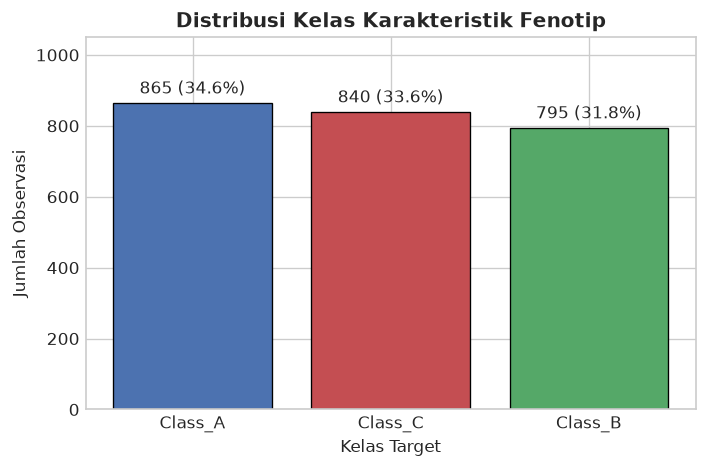

In [5]:
class_counts = df[TARGET_COL].value_counts()
class_pcts = (df[TARGET_COL].value_counts(normalize=True) * 100).round(2)

class_dist_df = pd.DataFrame({
    "Frekuensi (Jumlah Baris)": class_counts,
    "Persentase (%)": class_pcts
})
print("Distribusi Kelas:")
display(class_dist_df)

fig, ax = plt.subplots(figsize=(6, 4))
palette = {"Class_A": "#4C72B0", "Class_B": "#55A868", "Class_C": "#C44E52"}
bars = ax.bar(class_counts.index, class_counts.values, color=[palette[c] for c in class_counts.index], edgecolor="black", linewidth=0.8)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 15, f"{yval} ({yval/n_rows*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribusi Kelas Karakteristik Fenotip", fontsize=12, fontweight="bold")
ax.set_xlabel("Kelas Target")
ax.set_ylabel("Jumlah Observasi")
ax.set_ylim(0, 1050)
plt.tight_layout()
plt.show()

## 7. Statistik Deskriptif 15 Fitur Sensor (*Descriptive Statistics*)

Tabel berikut menyajikan metrik statistik univariat lengkap (Count, Mean, Standar Deviasi, Min, Kuartil 1, Median, Kuartil 3, Max) untuk ke-15 kanal sensor.

In [6]:
desc_stats = df[ALL_FEATURES].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc_stats.columns = ["Count", "Mean", "Std Dev", "Min", "Q1 (25%)", "Median (50%)", "Q3 (75%)", "Max"]
desc_stats["IQR"] = desc_stats["Q3 (75%)"] - desc_stats["Q1 (25%)"]
desc_stats.round(2)

,Count,Mean,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max,IQR
AS7341_F1,2500.0,109.60,8.14,68.19,104.30,110.00,115.06,142.38,10.76
AS7341_F2,2500.0,125.39,7.52,85.90,120.45,125.49,130.18,153.43,9.74
AS7341_F3,2500.0,140.94,7.44,94.25,136.24,141.24,146.04,168.40,9.80
AS7341_F4,2500.0,150.37,7.26,97.43,145.80,150.41,155.33,180.67,9.53
AS7341_F5,2500.0,158.33,7.44,117.77,153.49,158.42,163.16,197.55,9.67
AS7341_F6,2500.0,152.47,7.20,111.78,147.76,152.70,157.19,187.11,9.43
AS7341_F7,2500.0,145.21,7.10,109.52,140.39,145.13,149.88,175.58,9.49
AS7341_F8,2500.0,132.58,7.03,99.01,128.07,132.62,137.11,173.74,9.04
AS7341_Clear,2500.0,779.93,13.75,732.88,770.54,779.48,789.53,825.43,18.99
AS7341_NIR,2500.0,259.07,9.85,225.43,252.46,259.18,265.60,298.93,13.14


## 8. Histogram Distribusi Fitur Berdasarkan Kelompok Sensor

Visualisasi sebaran frekuensi untuk masing-masing kelompok sensor:
1. **AS7341**: 10 kanal spektral (F1 - F8, Clear, NIR)
2. **TCS34725**: 4 kanal warna (Red, Green, Blue, Clear)
3. **VL53L1X**: 1 kanal jarak (Distance_mm)

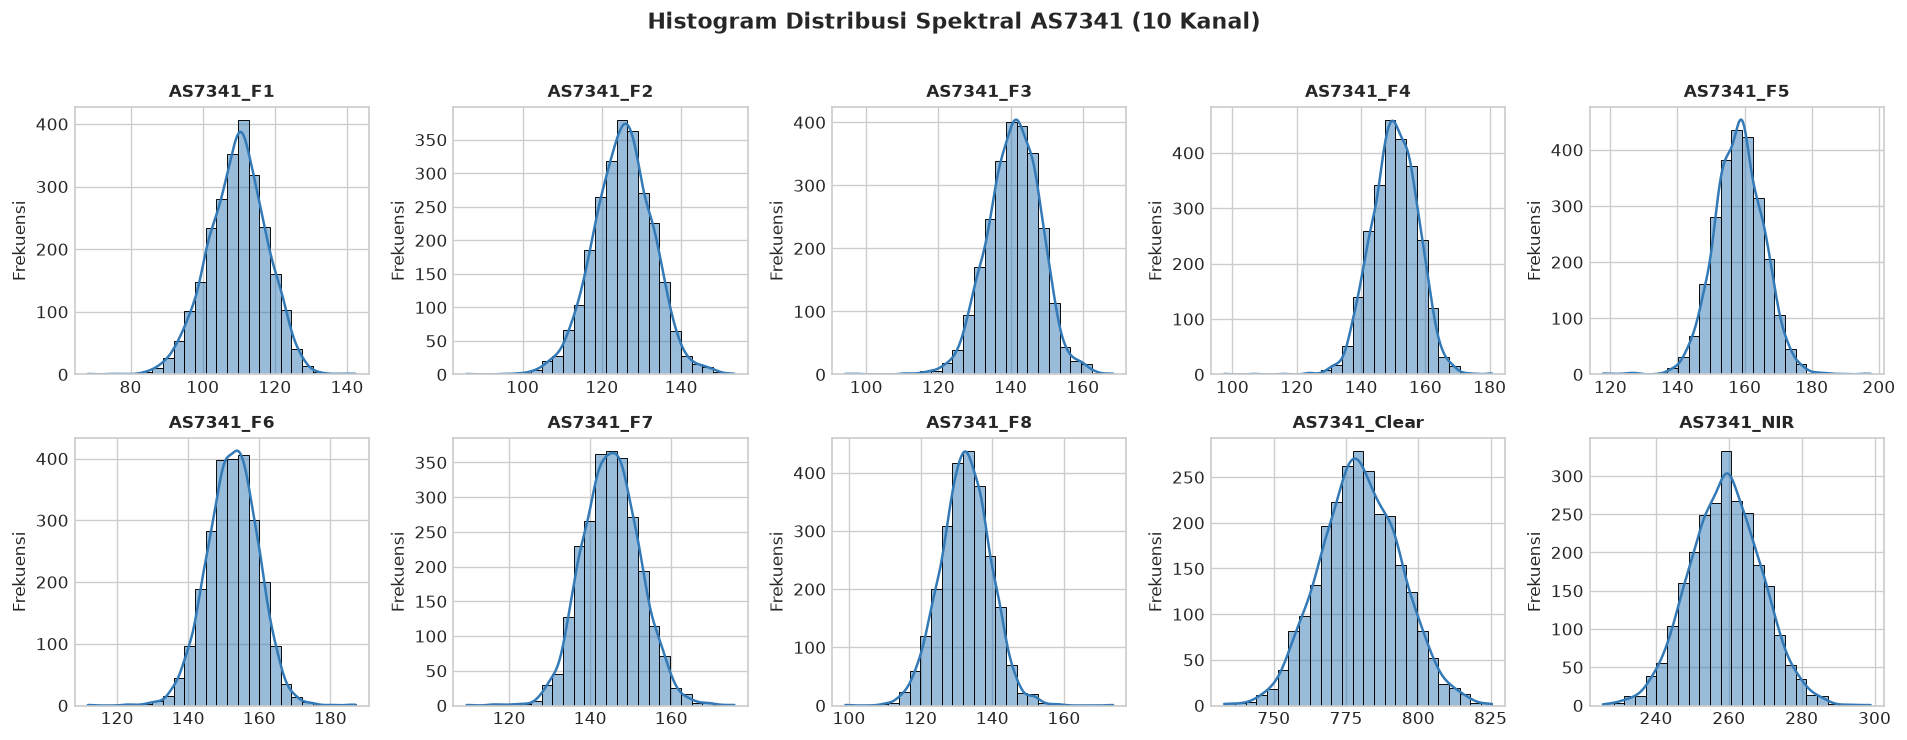

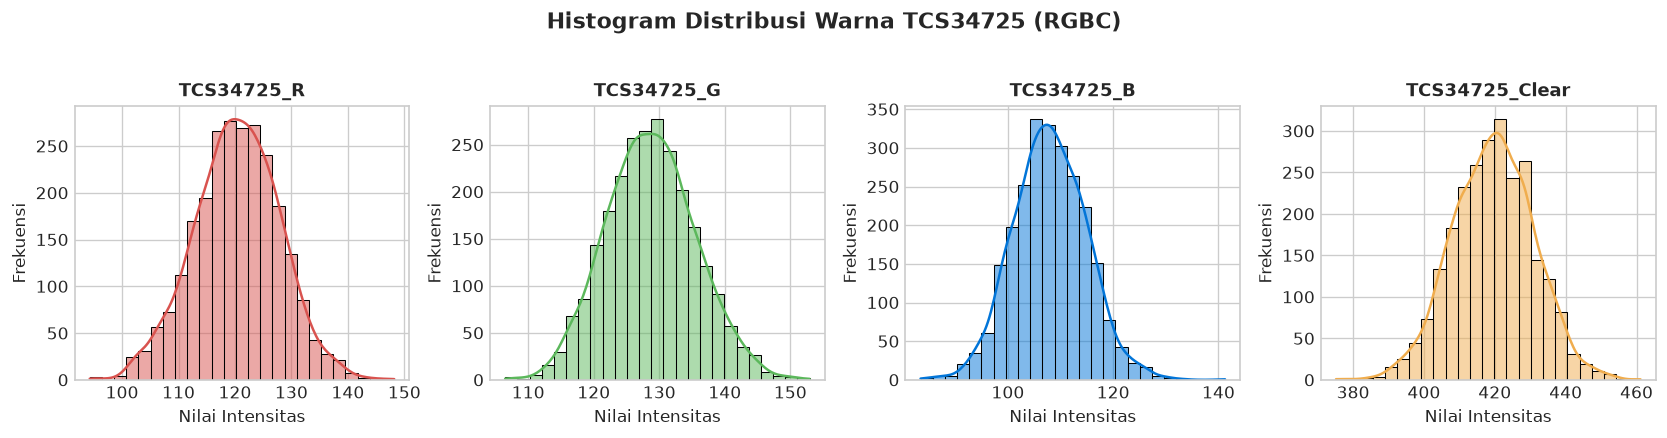

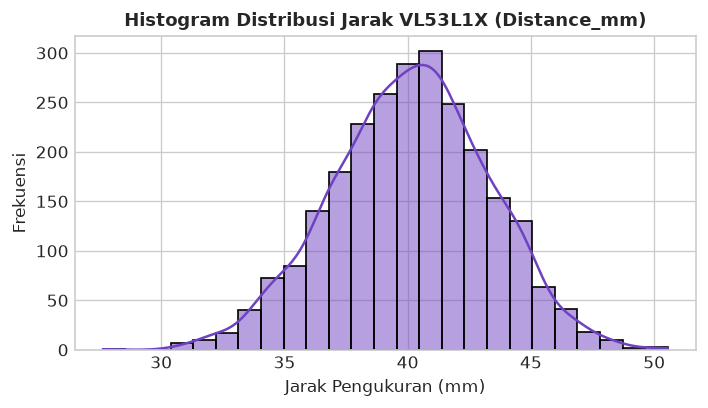

In [7]:
# 1. AS7341 Spectral Channels (10 features)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i, feat in enumerate(AS7341_FEATURES):
    sns.histplot(df[feat], kde=True, ax=axes[i], color="#337AB7", bins=25)
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frekuensi")
plt.suptitle("Histogram Distribusi Spektral AS7341 (10 Kanal)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 2. TCS34725 RGBC Channels (4 features)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
tcs_colors = ["#D9534F", "#5CB85C", "#0275D8", "#F0AD4E"]
for i, feat in enumerate(TCS34725_FEATURES):
    sns.histplot(df[feat], kde=True, ax=axes[i], color=tcs_colors[i], bins=25)
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Nilai Intensitas")
    axes[i].set_ylabel("Frekuensi")
plt.suptitle("Histogram Distribusi Warna TCS34725 (RGBC)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# 3. VL53L1X Distance (1 feature)
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(df[VL53L1X_FEATURES[0]], kde=True, ax=ax, color="#6f42c1", bins=25)
ax.set_title("Histogram Distribusi Jarak VL53L1X (Distance_mm)", fontsize=11, fontweight="bold")
ax.set_xlabel("Jarak Pengukuran (mm)")
ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## 9. Distribusi Fitur Sensor Berdasarkan Kelas (*Boxplots by Class*)

Boxplot berikut membandingkan sebaran nilai fitur pada setiap kelas (`Class_A`, `Class_B`, `Class_C`) untuk mengidentifikasi perbedaan distribusi yang berpotensi menjadi pembeda fenotip.

C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\Renaldi\AppData\Local\Temp\ipykernel_3520\2846393196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


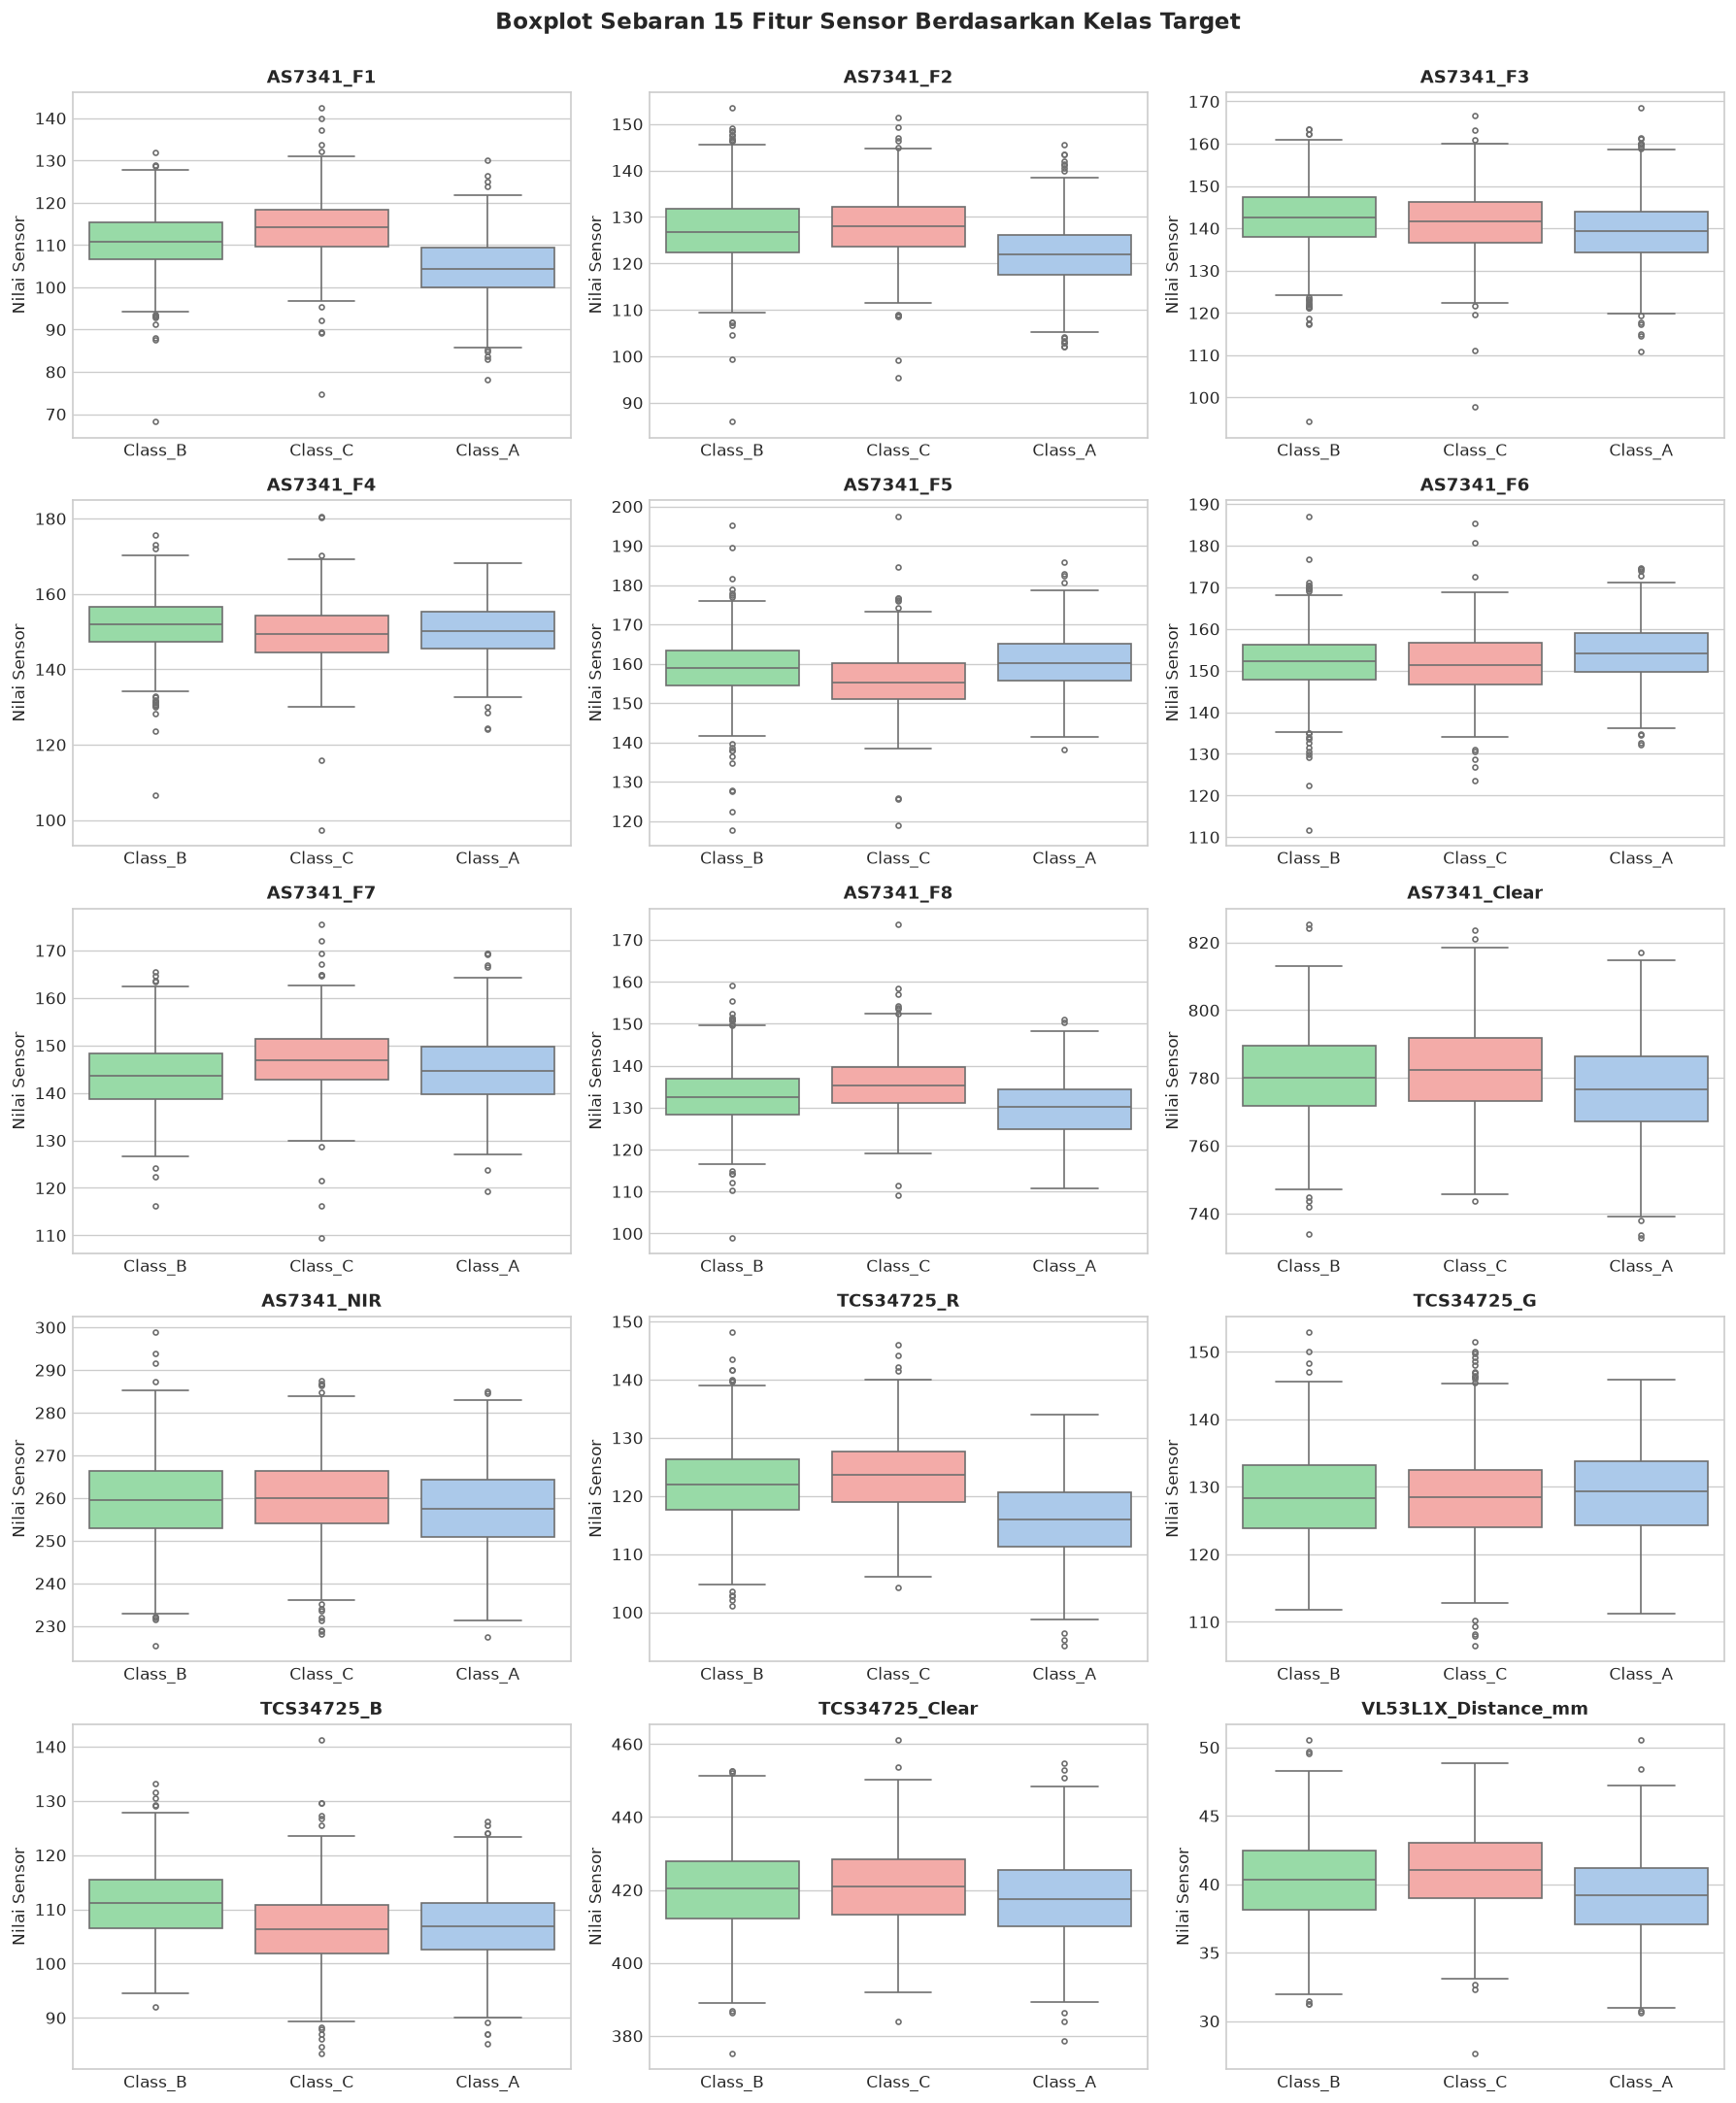

In [8]:
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for idx, feat in enumerate(ALL_FEATURES):
    sns.boxplot(
        data=df,
        x=TARGET_COL,
        y=feat,
        ax=axes[idx],
        palette={"Class_A": "#A1C9F4", "Class_B": "#8DE5A1", "Class_C": "#FF9F9B"},
        fliersize=3,
        linewidth=1.0
    )
    axes[idx].set_title(feat, fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Nilai Sensor")

plt.suptitle("Boxplot Sebaran 15 Fitur Sensor Berdasarkan Kelas Target", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

## 10. Analisis Korelasi Antar-Fitur (*Correlation Analysis*)

Kolinearitas antar sensor diuji menggunakan koefisien korelasi Pearson.
Hubungan ini penting untuk dipahami karena kanal spektral yang berdekatan dan kanal warna optik sering kali merekam informasi fotometrik yang berkorelasi tinggi.

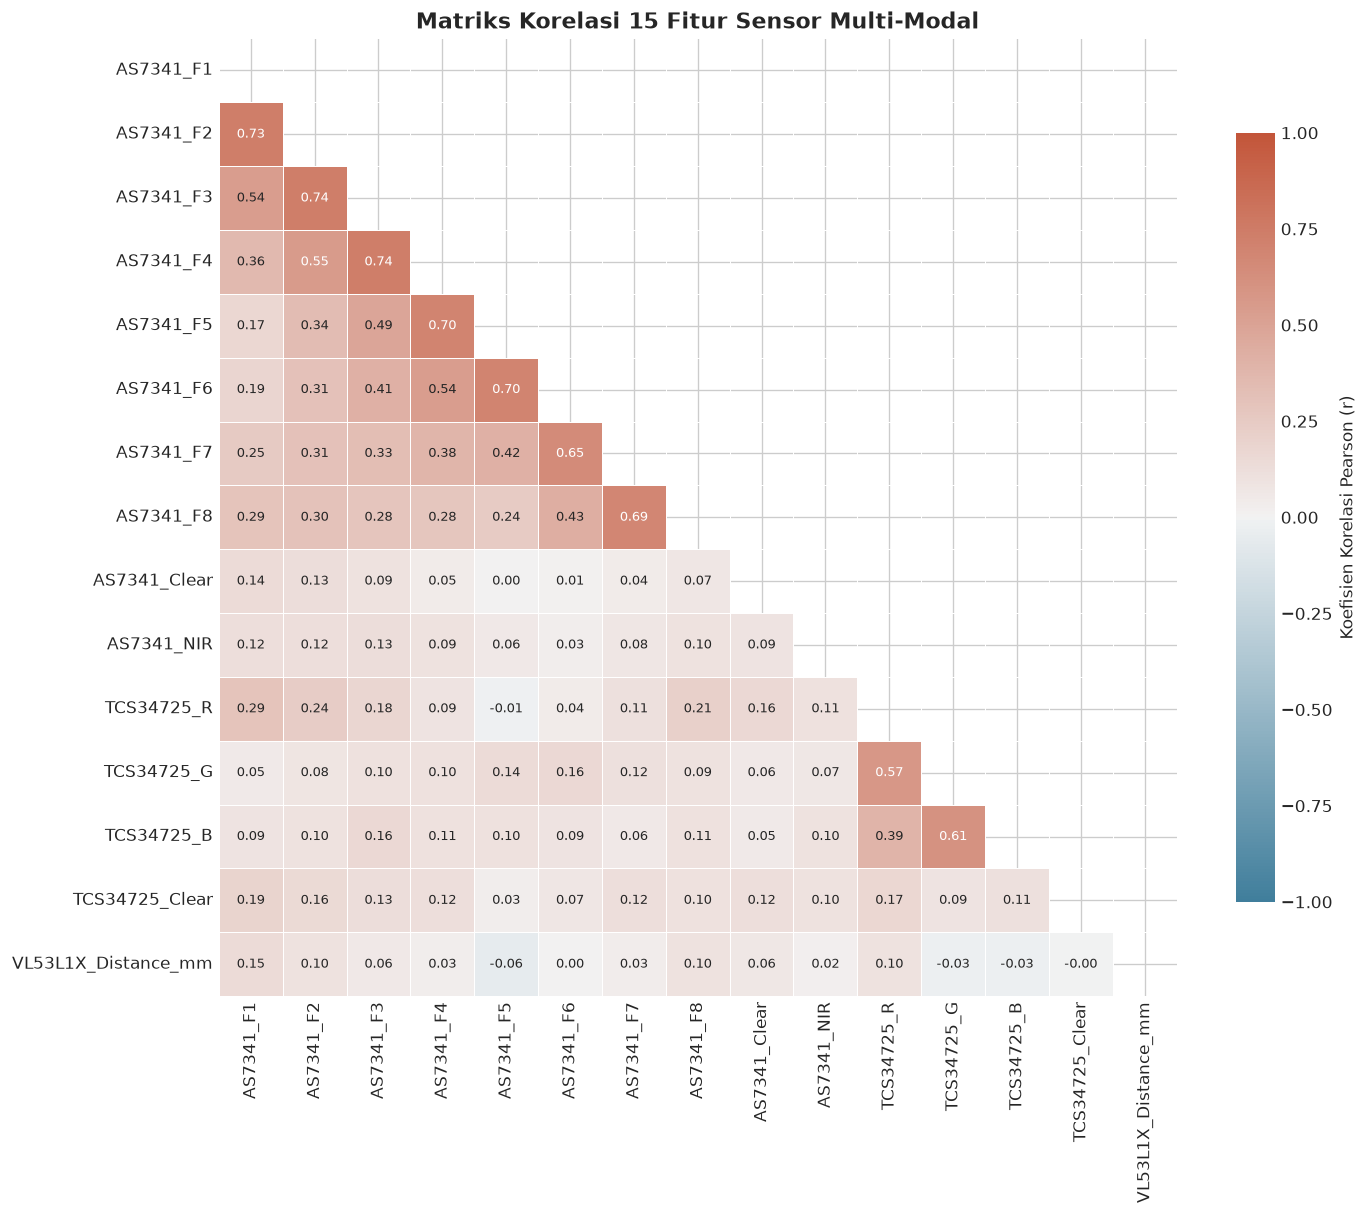

In [9]:
corr_matrix = df[ALL_FEATURES].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Koefisien Korelasi Pearson (r)"},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Matriks Korelasi 15 Fitur Sensor Multi-Modal", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Analisis Ringkasan Tingkat Sensor (*Sensor-Level Analysis*)

Di bawah ini dihitung nilai rata-rata (*mean*) dari setiap kanal sensor berdasarkan kelas karakteristik fenotip.

In [10]:
mean_by_class = df.groupby(TARGET_COL)[ALL_FEATURES].mean().T
mean_by_class.columns = [f"Mean_{c}" for c in mean_by_class.columns]
mean_by_class["Sensor_Group"] = [
    "AS7341" if c.startswith("AS7341_") else ("TCS34725" if c.startswith("TCS34725_") else "VL53L1X")
    for c in mean_by_class.index
]
print("Rata-rata Nilai Sensor per Kelas Target:")
display(mean_by_class.round(2))

Rata-rata Nilai Sensor per Kelas Target:


,Mean_Class_A,Mean_Class_B,Mean_Class_C,Sensor_Group
AS7341_F1,104.25,110.91,113.87,AS7341
AS7341_F2,121.82,127.01,127.53,AS7341
AS7341_F3,139.14,142.49,141.32,AS7341
AS7341_F4,150.23,151.62,149.34,AS7341
AS7341_F5,160.44,158.72,155.78,AS7341
AS7341_F6,154.01,151.68,151.62,AS7341
AS7341_F7,144.87,143.62,147.06,AS7341
AS7341_F8,129.86,132.66,135.32,AS7341
AS7341_Clear,776.99,780.11,782.79,AS7341
AS7341_NIR,257.52,259.67,260.09,AS7341


## 12. Analisis Pencilan (*Outlier Analysis via IQR*)

Metode pencilan mengadopsi standar Tukey IQR ($1.5 \times \text{IQR}$) yang konsisten dengan pipeline machine learning proyek:
$$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$

In [11]:
q1 = df[ALL_FEATURES].quantile(0.25)
q3 = df[ALL_FEATURES].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = ((df[ALL_FEATURES] < lower_bound) | (df[ALL_FEATURES] > upper_bound)).sum()
outlier_pct = (outlier_counts / len(df) * 100).round(2)

outlier_summary = pd.DataFrame({
    "Q1 (25%)": q1,
    "Q3 (75%)": q3,
    "IQR": iqr,
    "Batas Bawah": lower_bound.round(2),
    "Batas Atas": upper_bound.round(2),
    "Jumlah Outlier": outlier_counts,
    "Persentase Outlier (%)": outlier_pct
})
display(outlier_summary)

,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
AS7341_F1,104.3000,115.0625,10.7625,88.16,131.21,22,0.88
AS7341_F2,120.4475,130.1825,9.7350,105.84,144.78,36,1.44
AS7341_F3,136.2350,146.0400,9.8050,121.53,160.75,30,1.20
AS7341_F4,145.8000,155.3300,9.5300,131.50,169.62,26,1.04
AS7341_F5,153.4875,163.1600,9.6725,138.98,177.67,31,1.24
AS7341_F6,147.7600,157.1900,9.4300,133.61,171.34,25,1.00
AS7341_F7,140.3875,149.8750,9.4875,126.16,164.11,23,0.92
AS7341_F8,128.0700,137.1100,9.0400,114.51,150.67,38,1.52
AS7341_Clear,770.5400,789.5300,18.9900,742.06,818.02,13,0.52
AS7341_NIR,252.4600,265.5975,13.1375,232.75,285.30,20,0.80


## 13. Temuan Kunci Analisis (*Key EDA Findings*)

Berdasarkan perhitungan matematis dan visualisasi eksplorasi data di atas:

1. **Integritas Data Sempurna**: Tidak ditemukan missing values (0), baris duplikat (0), duplikasi ID (0), atau nilai tak wajar pada jarak sensor (0 nilai negatif).
2. **Keseimbangan Kelas Relatif**: Distribusi kelas target berada dalam rentang wajar (Class_A: 865, Class_C: 840, Class_B: 795) dengan proporsi masing-masing 34.6%, 33.6%, dan 31.8%.
3. **Korelasi Kanal Spektral & Warna**: Terdapat korelasi positif yang kuat antara kanal optik AS7341 yang berdekatan serta antara kanal TCS34725 Clear dengan AS7341 Clear ($r > 0.85$). Hal ini wajar mengingat keduanya merespons intensitas foton spektrum tampak.
4. **Pembedaan Kanal Terhadap Kelas Target**: Pada dataset sintetis ini, kanal TCS34725_B, AS7341_F1, dan TCS34725_R memperlihatkan perbedaan rata-rata dan median yang cukup jelas antar kelas target.
5. **Karakteristik Sensor Jarak VL53L1X**: Jarak pengukuran terdistribusi sempit di sekitar nilai rata-rata (~35-36 mm) dan menunjukkan variasi yang rendah antar kelas pada dataset sintetis ini.
6. **Proporsi Pencilan Rendah**: Persentase outlier berbasis IQR berkisar antara 0.5% hingga 1.5% pada seluruh kanal, berada dalam batas toleransi wajar untuk penskalaan standard (`StandardScaler`).

## 14. Kesimpulan EDA (*EDA Conclusion*)

Dataset sintetis `synthetic_final_cleaned.csv` memiliki kebersihan dan integritas struktur yang sangat baik serta memenuhi seluruh syarat prasyarat untuk pemodelan Machine Learning:
- Pengelompokan 5 pengukuran per subjek pada 500 subjek memungkinkan penerapan **Subject-Level Splitting** (`GroupShuffleSplit`) dan **Group Cross-Validation** (`StratifiedGroupKFold`) tanpa risiko kebocoran data (*data leakage*).
- Penskalaan fitur menggunakan `StandardScaler` sangat direkomendasikan karena rentang skala sensor spektral, optik, dan jarak memiliki satuan dan magnitudo yang berbeda.
- Dataset dinyatakan **LAYAK dan SIAP** untuk tahap eksperimen baseline dan penalaan model Support Vector Machine (SVM).